In [21]:
import os
import pathlib
import matplotlib.pyplot as plt
import json

node_logs = []

nodes = 10

for i in range(nodes):
    node = pathlib.Path(f"./results_sim/node_{i}").resolve()
    if node.exists():
        logs = node.glob("*.txt")
        latest_log = None
        for log in logs:
            if latest_log == None:
                latest_log = log
                continue
            current_timestamp = log.name.replace("log_","").replace(".txt","")
            lastest_timestamp = latest_log.name.replace("log_","").replace(".txt","")
            if float(current_timestamp)>float(lastest_timestamp):
                latest_log = log
        if latest_log:
            node_logs.append(json.loads(latest_log.read_text()))

print(node_logs)


[[[[0.5012498965592889, 0.28554718256965883, 0.22166285730474364, 0.1975979428223478, 0.18516721803604103, 0.1829820497309774, 0.17442259734602478, 0.16847474770090445, 0.1643529338686447, 0.16026367646891895, 0.16949507027743307, 0.16479926192905844, 0.1607525949555684, 0.1560073963449738, 0.15127491957046152, 0.16706598980155418, 0.16080296618061338, 0.15515227103984452, 0.15102774035034142, 0.14634210292280206, 0.16408310567096965, 0.1567668423238324, 0.15138995432393337, 0.1461331133495986, 0.14134303416784216, 0.16209278249643683, 0.153868361096072, 0.14871626380618994, 0.14224522097445116, 0.13589872010960813, 0.15949486044606542, 0.1503021115573441, 0.1425909714364424, 0.13743028114360523, 0.13182160421842481, 0.15779912408168723, 0.14683451912388568, 0.14007380853096643, 0.13403148028424117, 0.12692101969103503, 0.15441711237881242, 0.14307547992140782, 0.13637410555549753, 0.12918355976178394, 0.12344887507397954, 0.15249232714617156, 0.1411155992285992, 0.13261274754153035, 0

In [22]:

import numpy as np

numpy_logs = np.array(node_logs)
average_logs = np.mean(numpy_logs,axis=0).tolist()

avg_train_loss = average_logs[0][0]
avg_train_acc = average_logs[0][1]
avg_val_loss = average_logs[1][0]
avg_val_acc = average_logs[1][1]

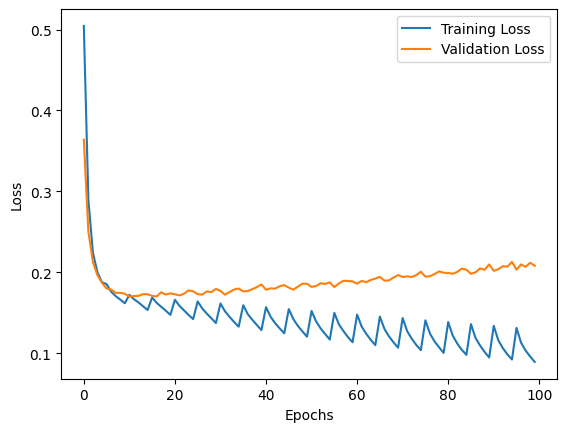

In [23]:
plt.plot(avg_train_loss,label="Training Loss")
plt.plot(avg_val_loss,label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [24]:
columns = ('Training Accuracy', 'Validation Accuracy')
rows = [1,5,10, 25, 50, 75, 100]

train_accs = [f"{round(avg_train_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
val_accs = [f"{round(avg_val_acc[rows[i]-1]*100,3)}%" for i in range(len(rows))]
import pandas as pd

pd.DataFrame(np.transpose([train_accs,val_accs]),columns=columns,index=rows)

,Training Accuracy,Validation Accuracy
1,79.491%,93.316%
5,94.857%,94.917%
10,94.931%,94.881%
25,95.208%,94.721%
50,95.795%,94.464%
75,96.346%,94.242%
100,96.868%,94.074%


In [25]:
val_max = max(avg_val_acc)
print(f"Best Validation Accuracy : {round(val_max*100,3)}%")

Best Validation Accuracy : 94.917%
